📂 Por favor, selecciona el archivo CSV generado por el MINER v41.0


Saving MINER_v41_Boom 1000 Index_20240101_MALLA_DATA_historico.csv to MINER_v41_Boom 1000 Index_20240101_MALLA_DATA_historico.csv
🚀 Procesando archivo: MINER_v41_Boom 1000 Index_20240101_MALLA_DATA_historico.csv

✅ Análisis iniciado: 1534705 registros detectados.

--- RESUMEN DE DISCRETIZACIÓN MATEMÁTICA ---
       node_m2  price
count      0.0    0.0
mean       NaN    NaN
std        NaN    NaN
min        NaN    NaN
25%        NaN    NaN
50%        NaN    NaN
75%        NaN    NaN
max        NaN    NaN

--- ANÁLISIS DE RUPTURAS ---
Escapes por el Techo (>144): 0 registros
Escapes por el Suelo (<0): 0 registros


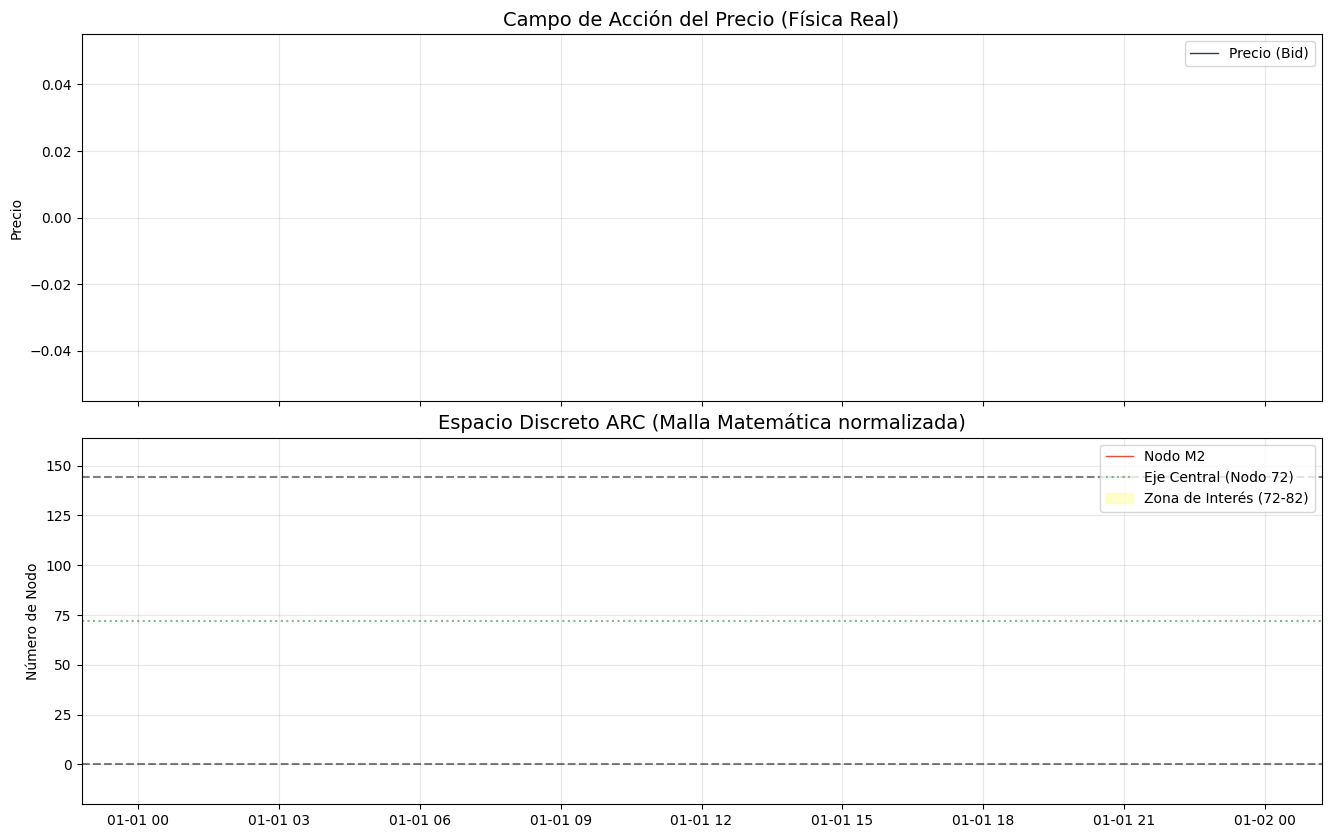

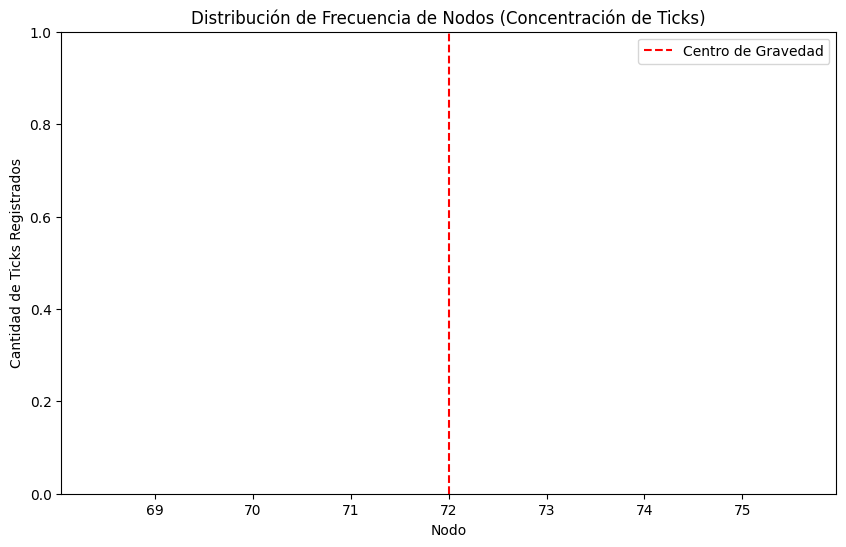

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from datetime import datetime
from google.colab import files
import io

# --- MOTOR DE ANÁLISIS ARC (Fidelidad 100%) ---

def analyze_arc_mining(file_path):
    """
    Función de deconstrucción geométrica del precio frente a la malla.
    Mantiene la lógica original de discretización y análisis de escapes.
    """
    # 1. Carga de datos con el delimitador detectado (;)
    try:
        # En Colab, el archivo se pasa como una ruta de cadena tras la carga
        df = pd.read_csv(file_path, sep=';', parse_dates=['timestamp'])
        print(f"\n✅ Análisis iniciado: {len(df)} registros detectados.")
    except Exception as e:
        print(f"❌ Error al procesar el archivo: {e}")
        return

    # 2. Limpieza y Preparación (Axioma de Integridad)
    df = df.dropna()
    df['node_m2'] = pd.to_numeric(df['node_m2'], errors='coerce')
    df['price'] = pd.to_numeric(df['price'], errors='coerce')

    # 3. Análisis Estadístico de la Discretización
    print("\n--- RESUMEN DE DISCRETIZACIÓN MATEMÁTICA ---")
    print(df[['node_m2', 'price']].describe())

    # 4. VISUALIZACIÓN: EL CAMPO DE PRECIO FRENTE A LA MALLA
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10), sharex=True)
    plt.subplots_adjust(hspace=0.1)

    # Gráfico Superior: Precio Real (Física del Mercado)
    ax1.plot(df['timestamp'], df['price'], color='#2c3e50', linewidth=1, label='Precio (Bid)')
    ax1.set_title('Campo de Acción del Precio (Física Real)', fontsize=14)
    ax1.set_ylabel('Precio')
    ax1.grid(True, alpha=0.3)
    ax1.legend()

    # Gráfico Inferior: Discretización en la Malla ARC (Espacio Discreto)
    ax2.plot(df['timestamp'], df['node_m2'], color='#e74c3c', linewidth=1, label='Nodo M2')
    ax2.axhline(y=0, color='black', linestyle='--', alpha=0.5)
    ax2.axhline(y=72, color='green', linestyle=':', alpha=0.5, label='Eje Central (Nodo 72)')
    ax2.axhline(y=144, color='black', linestyle='--', alpha=0.5)

    # Resaltar Zona Gloria/Poder (72-82) según la Tesis
    ax2.fill_between(df['timestamp'], 72, 82, color='yellow', alpha=0.2, label='Zona de Interés (72-82)')

    ax2.set_title('Espacio Discreto ARC (Malla Matemática normalizada)', fontsize=14)
    ax2.set_ylabel('Número de Nodo')
    ax2.set_ylim(-20, 164)  # Margen para observar rupturas/escapes
    ax2.grid(True, alpha=0.3)
    ax2.legend()

    # 5. HISTOGRAMA DE NODOS (Perfil de Volumen Matemático)
    plt.figure(figsize=(10, 6))
    sns.histplot(df['node_m2'], bins=144, kde=True, color='#3498db')
    plt.axvline(x=72, color='red', linestyle='--', label='Centro de Gravedad')
    plt.title('Distribución de Frecuencia de Nodos (Concentración de Ticks)')
    plt.xlabel('Nodo')
    plt.ylabel('Cantidad de Ticks Registrados')
    plt.legend()

    # 6. IDENTIFICACIÓN DE RUPTURAS (Teorema de Escape)
    escapes_up = df[df['node_m2'] > 144]
    escapes_down = df[df['node_m2'] < 0]

    print(f"\n--- ANÁLISIS DE RUPTURAS ---")
    print(f"Escapes por el Techo (>144): {len(escapes_up)} registros")
    print(f"Escapes por el Suelo (<0): {len(escapes_down)} registros")

    plt.show()

# --- MÓDULO DE CARGA COLAB ---

def colab_loader():
    """
    Inyecta la capacidad de cargar archivos CSV directamente en el entorno Colab.
    """
    print("📂 Por favor, selecciona el archivo CSV generado por el MINER v41.0")
    uploaded = files.upload()

    if len(uploaded) == 0:
        print("❌ No se seleccionó ningún archivo.")
        return

    for filename in uploaded.keys():
        print(f"🚀 Procesando archivo: {filename}")
        analyze_arc_mining(filename)

# Ejecución automática en la celda de Colab
if __name__ == "__main__":
    colab_loader()